# 第三周作业  CNN网络练习

1.针对fashion_mnist数据集，设计一个CNN网络，训练fashion_mnist的分类操作，将准确率提高到92%以上！
请尝试通过优化网络层数与超参数、正则化等措施，提高准确率。
注意：输入数据需要有Channel维度，可以调用numpy的reshape函数将输入改为(28,28,1)

##### 打印loss变化曲线曲线，显示测试集最后的预测准确率、混淆矩阵、典型误判图像等。显示误判图像时请用文本标签标注，而不是类标号

#### 请与第二周MLP模型的结果指标进行比较，总结这两个模型在收敛速度与分类准确率的不同表现。


In [1]:
# 类别名称（英文与中文）
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_cnames = ['T恤','裤子','套头衫','连衣裙','外套','凉鞋','衬衫','运动鞋','包','短靴']

## 数据加载与预处理

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
# 为 CNN 添加 channel 维度并归一化
x_train = x_train.reshape(-1,28,28,1).astype('float32') / 255.0
x_test = x_test.reshape(-1,28,28,1).astype('float32') / 255.0
# 标签独热编码
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh = to_categorical(y_test, num_classes=10)
print('processed shapes:', x_train.shape, y_train_oh.shape, x_test.shape, y_test_oh.shape)

processed shapes: (60000, 28, 28, 1) (60000, 10) (10000, 28, 28, 1) (10000, 10)


## 建立模型

In [4]:
from tensorflow.keras import models, layers

def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [5]:
model = build_cnn()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 32)       128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 28, 28, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 28, 28, 32)       128       
 hNormalization)                                                 
                                                                 
 activation_1 (Activation)   (None, 28, 28, 32)        0

In [6]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

## 训练模型

In [ ]:
# model = build_cnn()
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/50
422/422 - 5s - loss: 0.8269 - accuracy: 0.7045 - val_loss: 0.3981 - val_accuracy: 0.8598 - lr: 0.0010 - 5s/epoch - 11ms/step
Epoch 2/50
422/422 - 4s - loss: 0.5357 - accuracy: 0.8034 - val_loss: 0.3214 - val_accuracy: 0.8823 - lr: 0.0010 - 4s/epoch - 9ms/step
Epoch 3/50
422/422 - 4s - loss: 0.4714 - accuracy: 0.8291 - val_loss: 0.2888 - val_accuracy: 0.8918 - lr: 0.0010 - 4s/epoch - 9ms/step
Epoch 4/50
422/422 - 4s - loss: 0.4210 - accuracy: 0.8477 - val_loss: 0.2764 - val_accuracy: 0.8988 - lr: 0.0010 - 4s/epoch - 9ms/step
Epoch 5/50
422/422 - 4s - loss: 0.3938 - accuracy: 0.8587 - val_loss: 0.2522 - val_accuracy: 0.9108 - lr: 0.0010 - 4s/epoch - 8ms/step
Epoch 6/50
422/422 - 4s - loss: 0.3749 - accuracy: 0.8615 - val_loss: 0.2496 - val_accuracy: 0.9128 - lr: 0.0010 - 4s/epoch - 8ms/step
Epoch 7/50
422/422 - 4s - loss: 0.3556 - accuracy: 0.8716 - val_loss: 0.2498 - val_accuracy: 0.9062 - lr: 0.0010 - 4s/epoch - 9ms/step
Epoch 8/50
422/422 - 4s - loss: 0.3388 - accuracy: 0.8

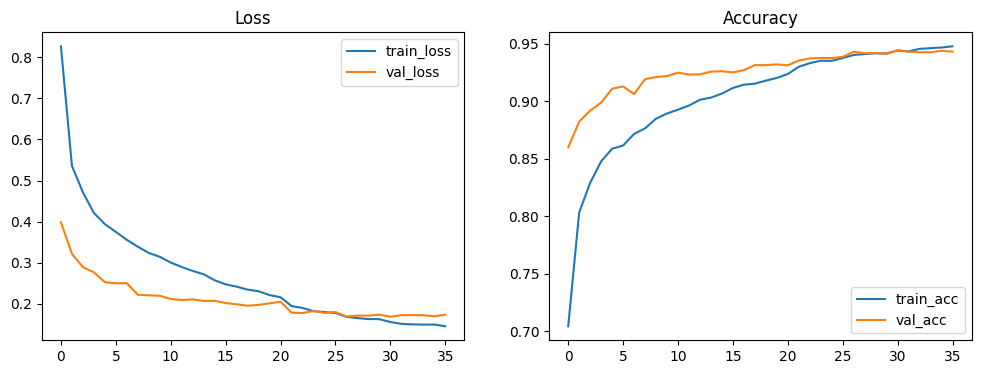

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=False),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(x_train, y_train_oh, validation_split=0.1, epochs=50, batch_size=128, callbacks=callbacks, verbose=2)

def plot_history(h):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.legend(); plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.legend(); plt.title('Accuracy')
    plt.show()

plot_history(history)

## 评估模型

In [24]:
scores = model.evaluate(x_test, y_test_oh)
print()
print('accuracy=', scores[1])
print(scores)

313/313 [==============================] - 1s 3ms/step - loss: 0.2035 - accuracy: 0.9353

accuracy= 0.9352999925613403
[0.20353029668331146, 0.9352999925613403]


## 进行预测

In [25]:
prediction = model.predict(x_test)
prediction_classes = prediction.argmax(axis=1)
print(prediction_classes)

313/313 [==============================] - 1s 2ms/step
[9 2 1 ... 8 1 5]


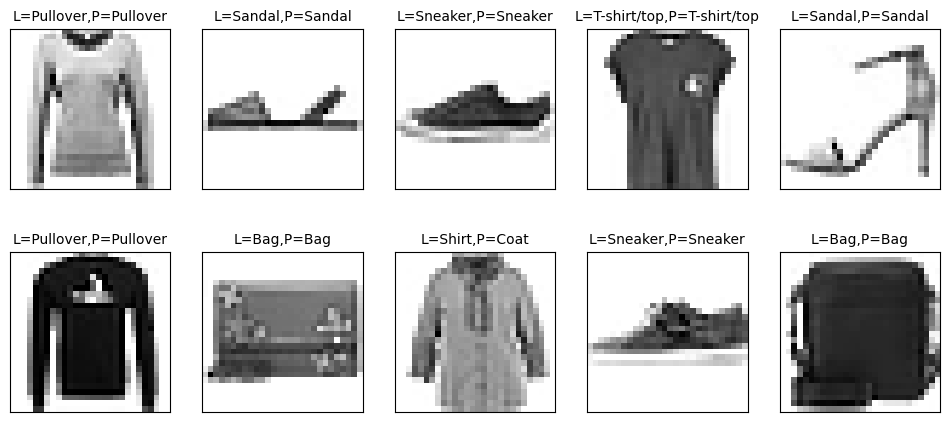

In [26]:
import matplotlib.pyplot as plt
def plot_images_labels_prediction(images, label, prediction, index, num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num > 25: num = 25
    for i in range(0, num):
        ax = plt.subplot(5, 5, i+1)
        ax.imshow(images[index], cmap='binary')
        title = 'L=' + str(class_names[label[index]])
        if len(prediction) > 0:
            title += ',P=' + str(class_names[prediction[index]])
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        index += 1
    plt.show()  

plot_images_labels_prediction(x_test.reshape(-1,28,28), y_test, prediction_classes, index=110)

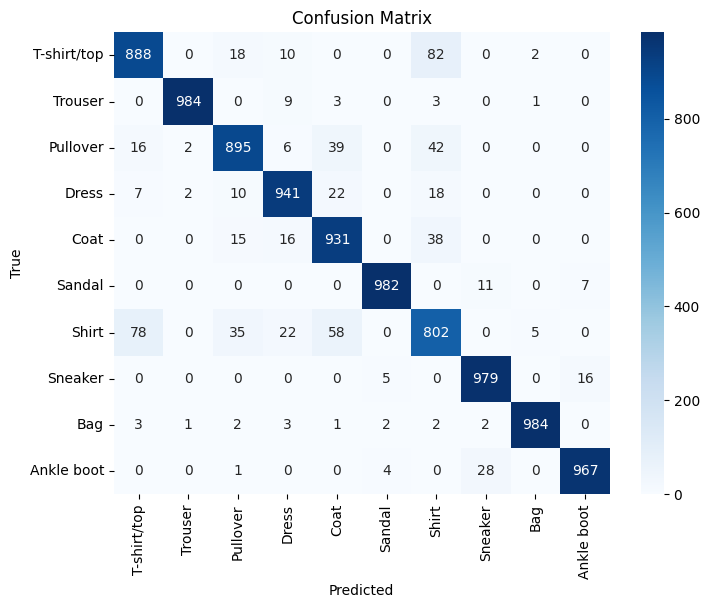

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, prediction_classes)      

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,                          # 混淆矩阵
    annot=True,                  # 在每个格子上显示数字
    fmt='d',                     # 整数格式（'d' 表示整数）
    cmap='Blues',                # 颜色风格（'Blues' 蓝白渐变，很经典）
    xticklabels=class_names,     # x轴标签（预测类别）
    yticklabels=class_names      # y轴标签（真实类别）
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()